In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # macOS
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스나 colab 등

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

In [3]:
rename_dict = {
    "일시": "날짜",
    "평균기온(°C)": "평균 기온",
    "최저기온(°C)": "최저 기온",
    "최고기온(°C)": "최고 기온",
    "일강수량(mm)": "강수량"
}

recent = pd.read_csv("./weather_csv/weather_data1.csv", encoding="cp949").rename(columns=rename_dict)
past = pd.read_csv("./weather_csv/weather_past_data1.csv", encoding="cp949").rename(columns=rename_dict)

df = pd.concat([recent, past], ignore_index=True)
df = df[["날짜", "평균 기온", "최저 기온", "최고 기온", "강수량"]]
df["날짜"] = pd.to_datetime(df["날짜"])
df["평균 기온"] = pd.to_numeric(df["평균 기온"], errors="coerce")
df["최저 기온"] = pd.to_numeric(df["최저 기온"], errors="coerce")
df["최고 기온"] = pd.to_numeric(df["최고 기온"], errors="coerce")
df["강수량"] = pd.to_numeric(df["강수량"], errors="coerce").fillna(0)

In [4]:
df.head()

,날짜,평균 기온,최저 기온,최고 기온,강수량
0,2020-01-01,-2.2,-6.5,0.3,0.1
1,2020-01-02,1.0,-0.7,3.8,0.0
2,2020-01-03,-0.1,-3.4,4.6,0.0
3,2020-01-04,1.2,-2.8,6.1,0.0
4,2020-01-05,1.3,-3.2,6.6,0.0


In [5]:
df.tail()

,날짜,평균 기온,최저 기온,최고 기온,강수량
3648,1999-12-27,0.7,-4.5,5.9,0.0
3649,1999-12-28,3.4,-0.4,6.6,1.3
3650,1999-12-29,0.2,-4.3,5.2,0.0
3651,1999-12-30,1.7,-3.5,7.7,0.0
3652,1999-12-31,3.5,0.0,7.3,0.0


In [6]:
solar_terms = {
    "입춘": "02-04", "우수": "02-19", "경칩": "03-05", "춘분": "03-20", "청명": "04-04", "곡우": "04-20",
    "입하": "05-05", "소만": "05-21", "망종": "06-05", "하지": "06-21", "소서": "07-07", "대서": "07-22",
    "입추": "08-07", "처서": "08-23", "백로": "09-07", "추분": "09-23", "한로": "10-08", "상강": "10-23",
    "입동": "11-07", "소설": "11-22", "대설": "12-07", "동지": "12-22", "소한": "01-05", "대한": "01-20"
}

In [7]:
# 절기 날짜 +-3일 계산

def extract_term_weather(df, term_dict, window=3):
    results = []
    for term, date_str in term_dict.items():
        for year in df["날짜"].dt.year.unique():
            try:
                term_date = pd.to_datetime(f"{year}-{date_str}")
            except:
                continue
            mask = (df["날짜"] >= term_date - pd.Timedelta(days=window)) & \
                   (df["날짜"] <= term_date + pd.Timedelta(days=window))
            subset = df[mask]
            if len(subset) > 0:
                results.append({
                    "절기": term,
                    "연도": year,
                    "평균기온": subset["평균 기온"].mean(),
                    "최저기온": subset["최저 기온"].mean(),
                    "최고기온": subset["최고 기온"].mean(),
                    "강수량": subset["강수량"].mean()
                })
    return pd.DataFrame(results)

In [16]:
# 절기 데이터
term_df = extract_term_weather(df, solar_terms)
term_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   절기      240 non-null    object 
 1   연도      240 non-null    int32  
 2   평균기온    240 non-null    float64
 3   최저기온    240 non-null    float64
 4   최고기온    240 non-null    float64
 5   강수량     240 non-null    float64
dtypes: float64(4), int32(1), object(1)
memory usage: 10.4+ KB


In [21]:
print(term_df)

     절기    연도      평균기온      최저기온      최고기온       강수량     기온 범위
0    입춘  2020 -2.042857 -6.028571  2.500000  0.242857  8.528571
1    입춘  2021  0.628571 -4.285714  4.728571  0.600000  9.014286
2    입춘  2022 -3.757143 -7.028571  0.314286  0.242857  7.342857
3    입춘  2023  0.700000 -3.257143  6.028571  0.000000  9.285714
4    입춘  2024  3.142857  0.300000  6.971429  0.585714  6.671429
..   ..   ...       ...       ...       ...       ...       ...
235  대한  1995 -0.542857 -3.985714  2.814286  0.657143  6.800000
236  대한  1996 -2.357143 -5.557143  1.428571  0.000000  6.985714
237  대한  1997 -4.071429 -7.914286  0.342857  0.000000  8.257143
238  대한  1998 -4.685714 -8.414286 -0.057143  0.414286  8.357143
239  대한  1999  1.714286 -2.242857  5.657143  0.000000  7.900000

[240 rows x 7 columns]


In [17]:
past_df = term_df[term_df["연도"].between(1995, 1999)].copy()
recent_df = term_df[term_df["연도"].between(2020, 2024)].copy()

##### 과거 5년 (1995~1999)

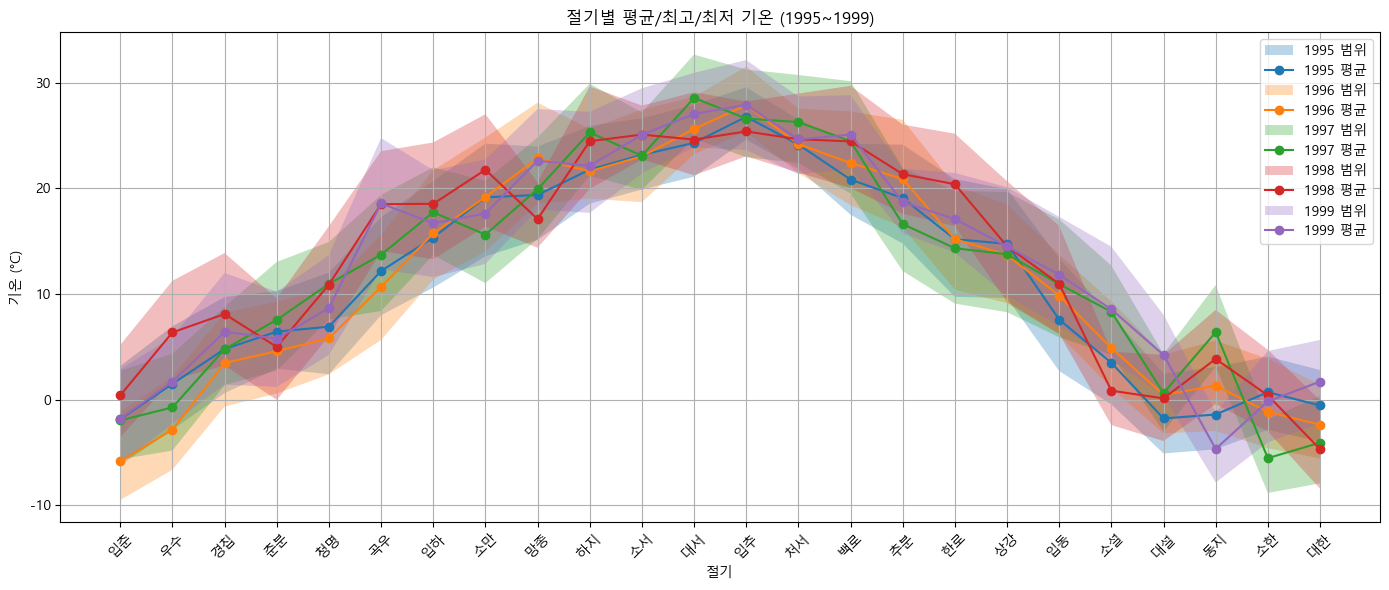

In [74]:
# 일교차 컬럼 추가
term_df['일교차'] = term_df['최고기온'] - term_df['최저기온']

# 절기 순서 정의 (보기 좋게 정렬)
term_order = list(solar_terms.keys())

# 시각화: 절기별 min~max 일교차 (연도별 선 그래프 + area)
plt.figure(figsize=(14, 6))
for year, df in past_df.groupby('연도'):
    df_sorted = df.set_index('절기').loc[term_order].reset_index()
    plt.fill_between(df_sorted['절기'], df_sorted['최저기온'], df_sorted['최고기온'], alpha=0.3, label=f"{year} 범위")
    plt.plot(df_sorted['절기'], df_sorted['평균기온'], marker='o', label=f"{year} 평균")

plt.xticks(rotation=45)
plt.xlabel("절기")
plt.ylabel("기온 (°C)")
plt.title("절기별 평균/최고/최저 기온 (1995~1999)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

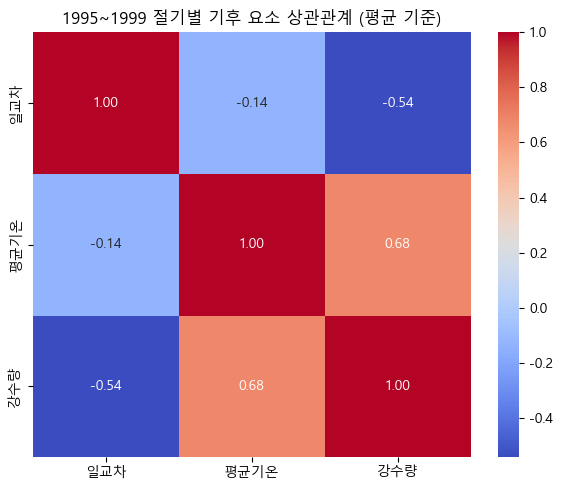

In [85]:
# 1. 일교차 컬럼 추가
past_df['일교차'] = past_df['최고기온'] - past_df['최저기온']

# 2. 절기별 평균값 계산
past_avg_df = past_df.groupby('절기')[['일교차', '평균기온', '강수량']].mean()

# 3. 상관관계 계산
corr_matrix = past_avg_df.corr()

# 4. 히트맵 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("1995~1999 절기별 기후 요소 상관관계 (평균 기준)")
plt.tight_layout()
plt.show()

##### 최근 5년 (2020~2024)

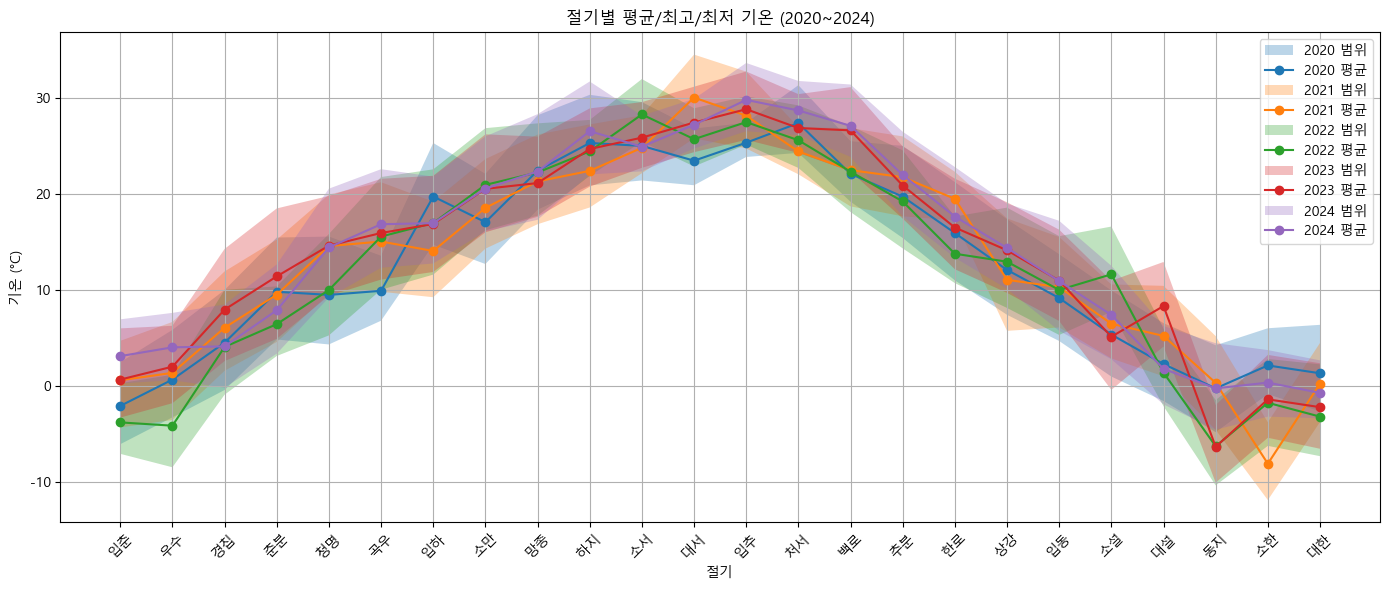

In [71]:
# 일교차 컬럼 추가
term_df['일교차'] = term_df['최고기온'] - term_df['최저기온']

# 절기 순서 정의 (보기 좋게 정렬)
term_order = list(solar_terms.keys())

# 시각화: 절기별 min~max 기온 범위 (연도별 선 그래프 + area)
plt.figure(figsize=(14, 6))
for year, df in recent_df.groupby('연도'):
    df_sorted = df.set_index('절기').loc[term_order].reset_index()
    plt.fill_between(df_sorted['절기'], df_sorted['최저기온'], df_sorted['최고기온'], alpha=0.3, label=f"{year} 범위")
    plt.plot(df_sorted['절기'], df_sorted['평균기온'], marker='o', label=f"{year} 평균")

plt.xticks(rotation=45)
plt.xlabel("절기")
plt.ylabel("기온 (°C)")
plt.title("절기별 평균/최고/최저 기온 (2020~2024)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

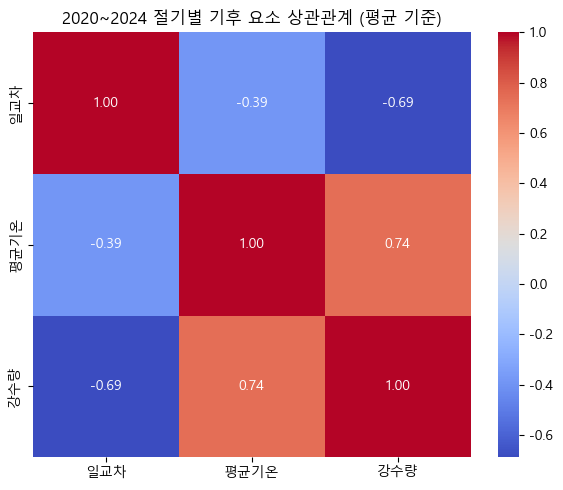

In [86]:
# 1. 일교차 컬럼 추가
recent_df['일교차'] = recent_df['최고기온'] - recent_df['최저기온']

# 2. 절기별 평균값 계산
recent_avg_df = recent_df.groupby('절기')[['일교차', '평균기온', '강수량']].mean()

# 3. 상관관계 계산
corr_matrix = recent_avg_df.corr()

# 4. 히트맵 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("2020~2024 절기별 기후 요소 상관관계 (평균 기준)")
plt.tight_layout()
plt.show()

##### 이상치 확인

In [77]:
def outliers(df, cols, term_col='절기'):
    outlier_rows = []

    for term, group in term_df.groupby(term_col):
        for col in cols:
            q1 = group[col].quantile(0.25)
            q3 = group[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            outliers = group[(group[col] < lower_bound) | (group[col] > upper_bound)].copy()
            outliers['이상치컬럼'] = col
            outliers['절기'] = term
            outlier_rows.append(outliers)

    return pd.concat(outlier_rows) if outlier_rows else pd.DataFrame()


In [79]:
cols_to_check = ['평균기온', '최저기온', '최고기온', '강수량']

# 과거 데이터 이상치
past_outliers = outliers(past_df, cols_to_check)

# 최근 데이터 이상치
recent_outliers = outliers(recent_df, cols_to_check)

# 결과 확인
print("과거 이상치 수:", len(past_outliers))
print("최근 이상치 수:", len(recent_outliers))


과거 이상치 수: 43
최근 이상치 수: 43


In [82]:
def draw_boxplot(df, col, title):
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='절기', y=col, data=df, showfliers=True)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()

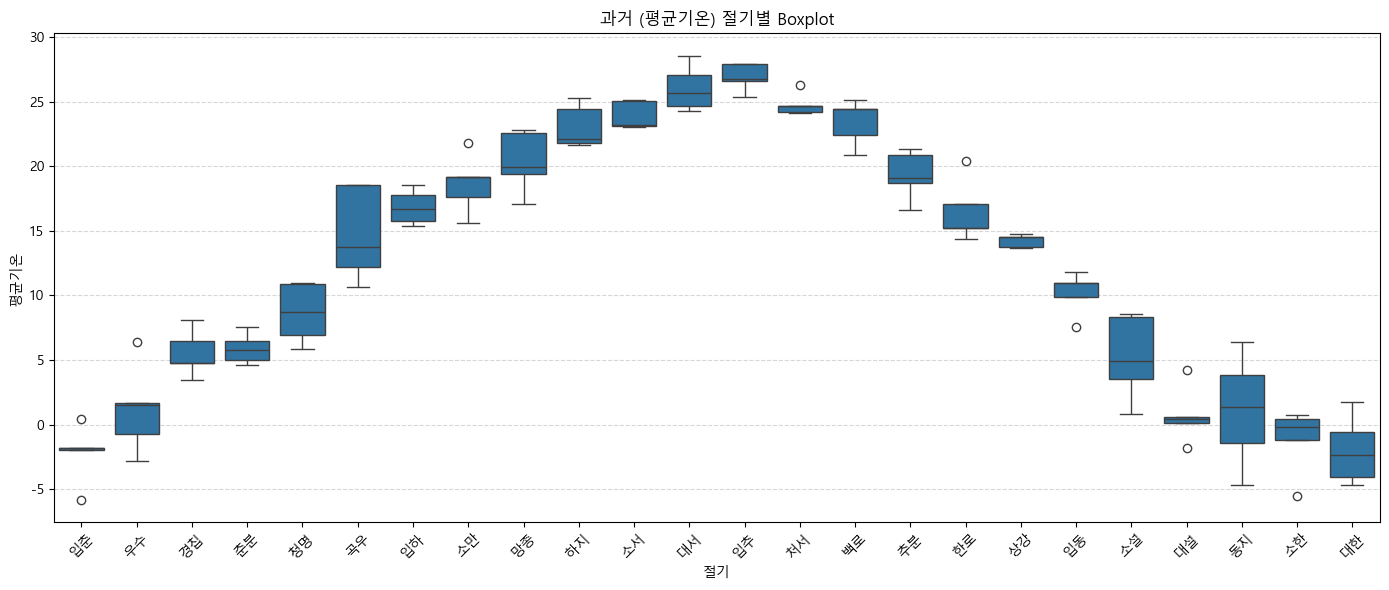

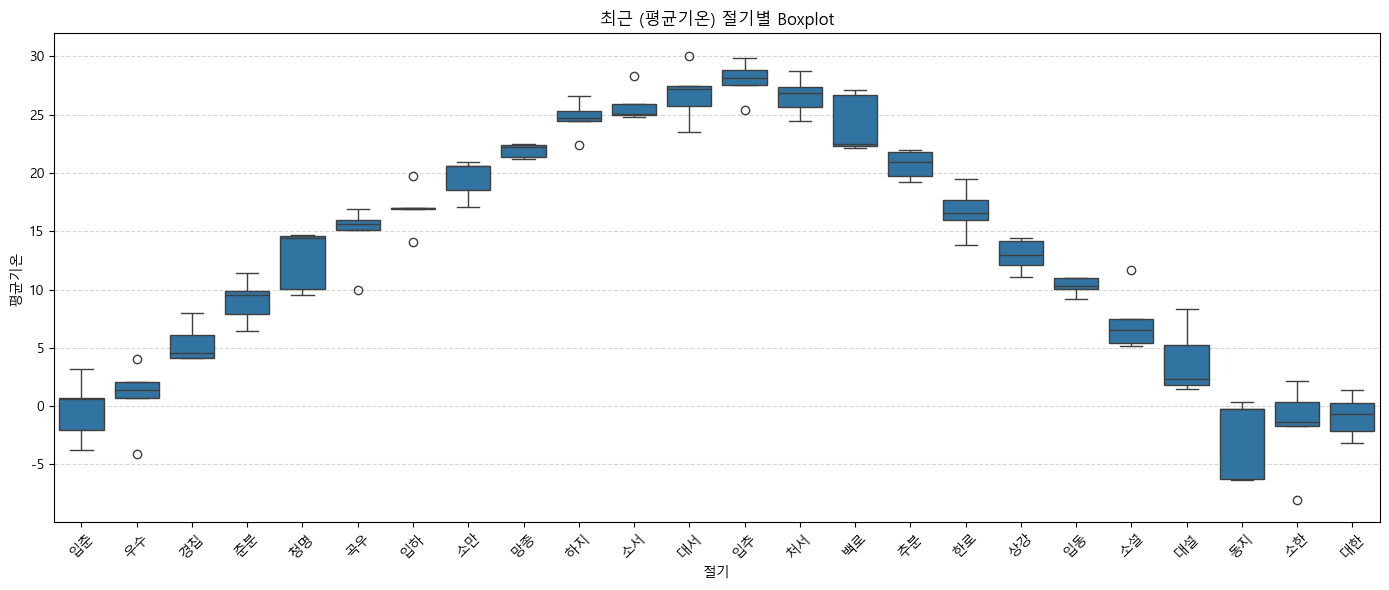

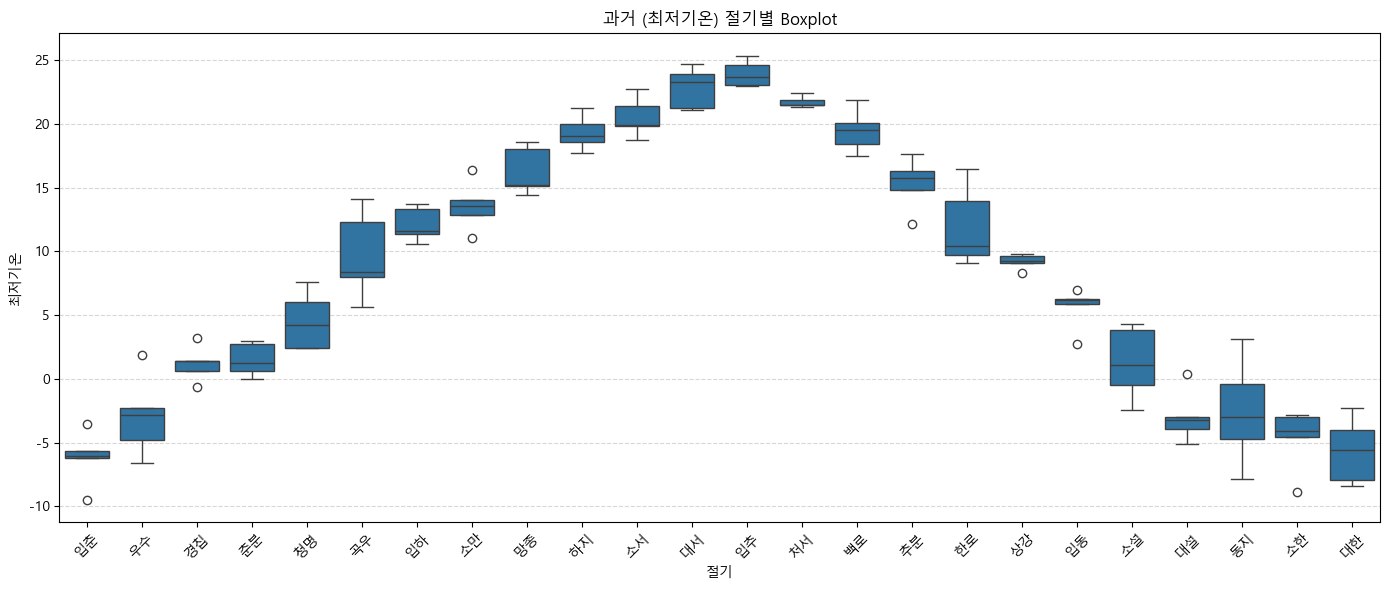

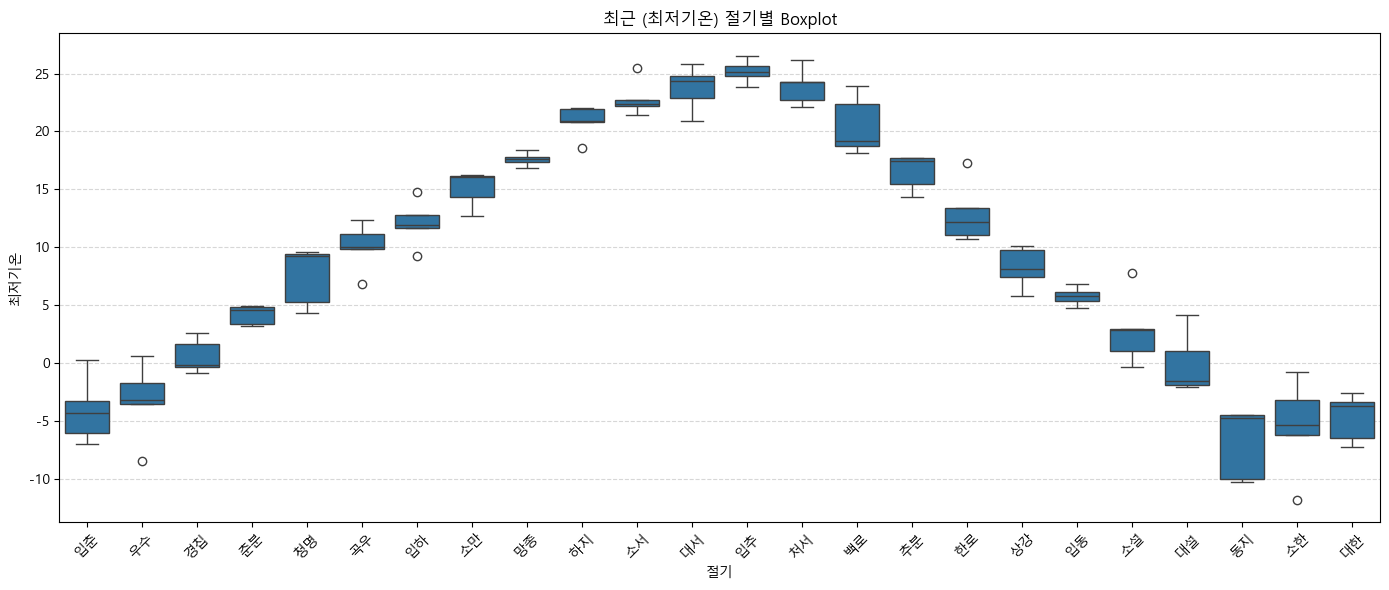

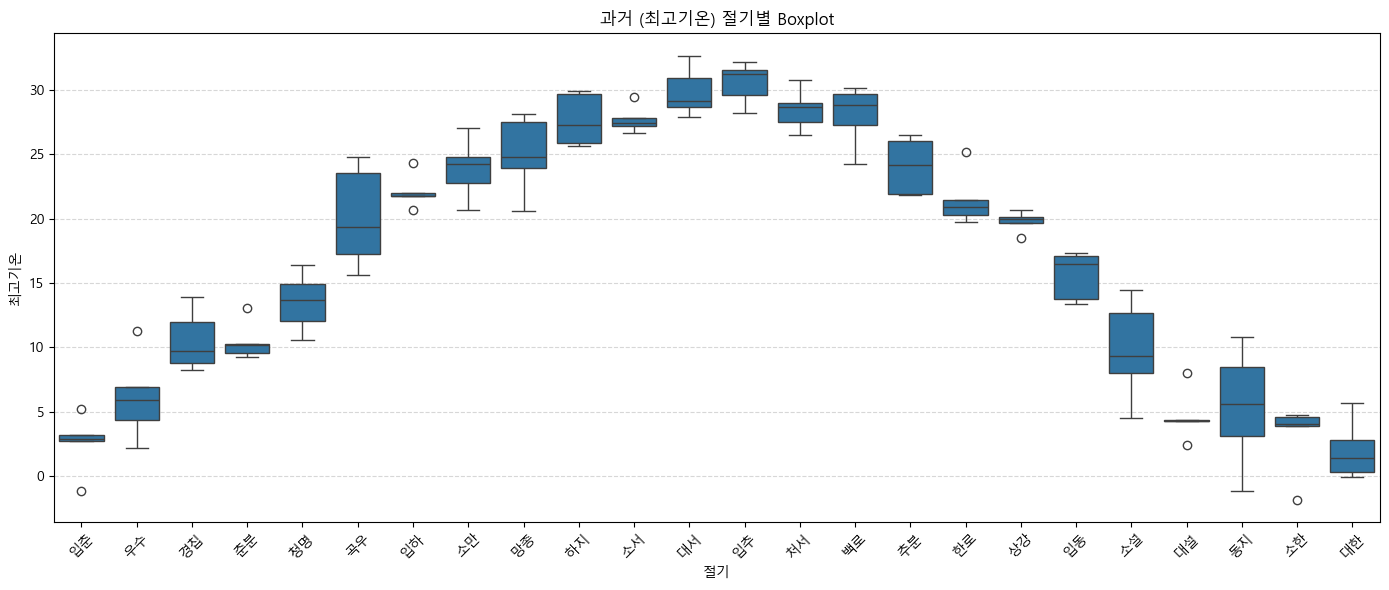

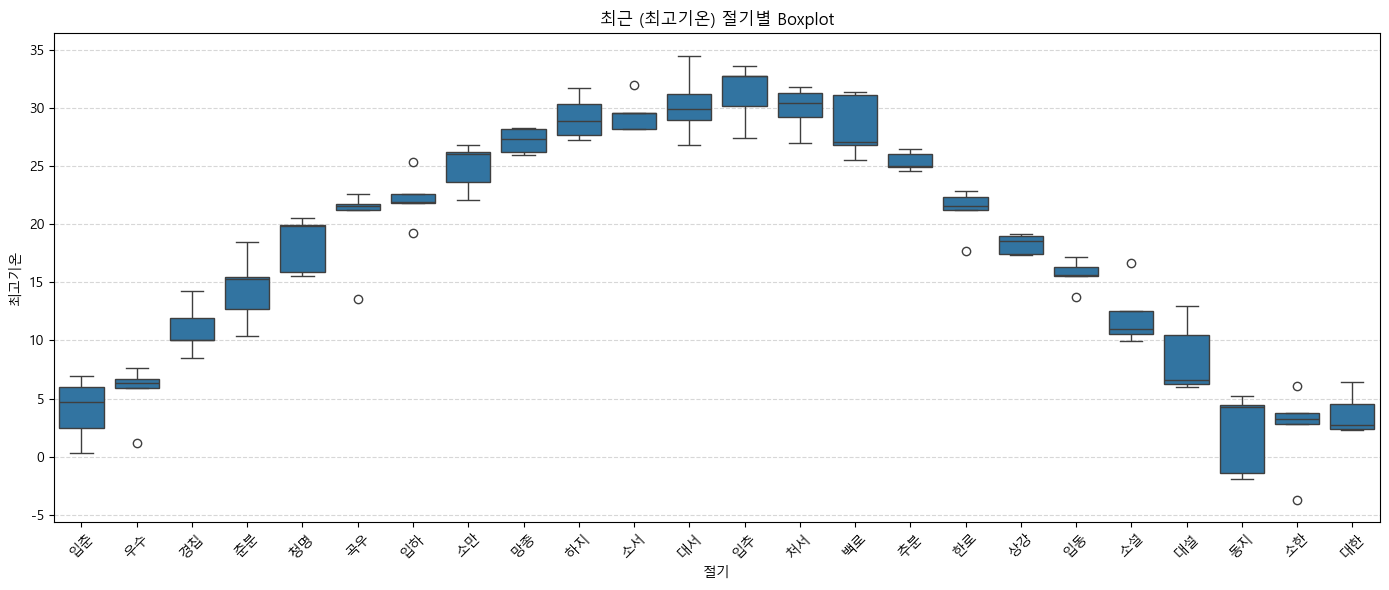

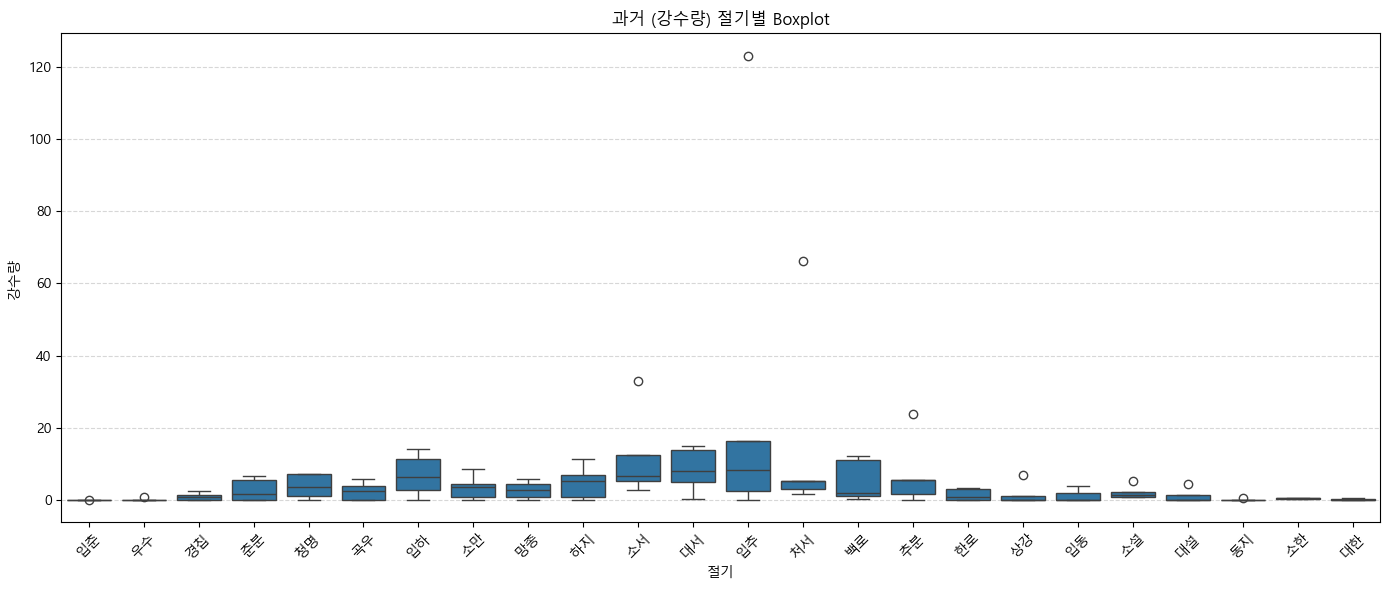

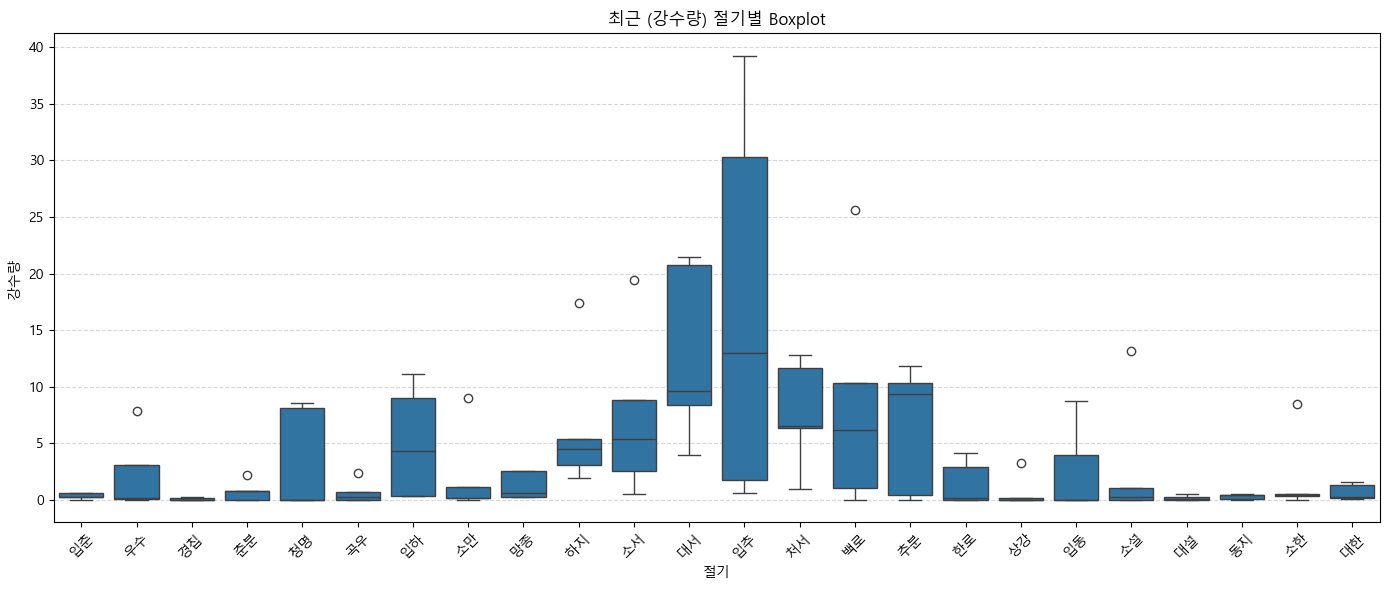

In [84]:
df_cols = ['평균기온', '최저기온', '최고기온', '강수량']

for col in df_cols:
    draw_boxplot(past_df, col, f"과거 ({col}) 절기별 Boxplot")
    draw_boxplot(recent_df, col, f"최근 ({col}) 절기별 Boxplot")